# Figure 3: Advanced Testing Results (Updated Layout)

## Layout:
- Row 1: Panel a (left) + Panel b (right)
- Row 2: Panel c (full width, horizontal)

## Panel a: Iteration Convergence of dE
- x: Iteration (1-5)
- y: Mean dE across 20 cases (dE = AdsMind energy - Reference energy)
- 4 backends as lines
- Shaded area: Min-max range across cases

## Panel b: Chemical Slip Analysis
- Grouped bar chart: x = Backend (4), y = Slip rate
- Grouped by surface family (Intermetallic vs Monometallic)

# Panel c: 4-Backend Agreement Heatmap
- x: Case ID (01-20)
- y: Backend (4)
- Colored by adsorption energy (RdYlBu_r colormap)
- Annotated with energy values


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None
from matplotlib.patches import Patch

## Load All Data

In [2]:
# === Panel a data: iteration convergence ratios ===
BASE = '../../../'  # from paper_plots/figure4/ to AdsMind project root

df_iter = pd.read_csv(f'{BASE}/research/results/processed/figure4/iteration_convergence.csv')

# Calculate ratio: E_iter / E_full (final_best)
records_a = []
for _, row in df_iter.iterrows():
    case_id = int(row['case_id'])
    final_best = row.get('final_best')
    if pd.isna(final_best) or final_best == 0:
        continue
    for iter_num in range(1, 6):
        iter_col = f'iter_{iter_num}'
        if iter_col in row and pd.notna(row[iter_col]):
            ratio = row[iter_col] / final_best
            records_a.append({'case_id': case_id, 'backend': row['backend'],
                             'iteration': iter_num, 'ratio': ratio})
df_ratio = pd.DataFrame(records_a)

backends_in_data = df_ratio['backend'].unique().tolist()
print(f'Panel a data: {len(df_ratio)} records, backends: {backends_in_data}')
print("mean_ratio by iteration:", df_ratio.groupby(['iteration'])['ratio'].mean().reset_index())

Panel a data: 316 records, backends: ['gemini', 'openai_gpt54', 'anthropic_sonnet46', 'grok4']
mean_ratio by iteration:    iteration     ratio
0          1  0.964524
1          2  0.979692
2          3  0.985351
3          4  0.996256
4          5  1.000000


In [3]:
# === Panel b data: chemical slip ===
try:
    with open(f'{BASE}/research/results/processed/figure4/slip_analysis.json', encoding='utf-8-sig') as f:
        slip_data = json.load(f)
except UnicodeDecodeError:
    with open(f'{BASE}/research/results/processed/figure4/slip_analysis.json', encoding='gbk') as f:
        slip_data = json.load(f)
print(f'Panel b data loaded: overall slip rate = {slip_data["overall_slip_rate"]}')

Panel b data loaded: overall slip rate = {'gemini': 0.6842, 'gemini25pro_mace_mp0_small_n': '13/19', 'openai_gpt54': 0.5556, 'openai_gpt54_n': '10/18', 'anthropic_claude': 0.6667, 'anthropic_claude_n': '12/18', 'grok4': 0.7222, 'grok4_mace_mp0_small_n': '13/18'}


In [4]:
# === Panel c data: 4-backend comparison ===
df_ablation = pd.read_csv(f'{BASE}/research/results/processed/figure4/ablation_4backend.csv')
df_ablation_full = df_ablation[df_ablation['variant'] == 'full'].copy()
pivot = df_ablation_full.pivot(index='case_id', columns='backend', values='best_energy_eV')
print(f'Panel c data: {pivot.shape[0]} cases × {pivot.shape[1]} backends')
print(f'Backends: {pivot.columns.tolist()}')

Panel c data: 20 cases × 4 backends
Backends: ['claude', 'gemini', 'gpt', 'grok']


## Create & Save Figure 3 (All 3 Panels in ONE Figure)


Saved: .//figure4_complete.png


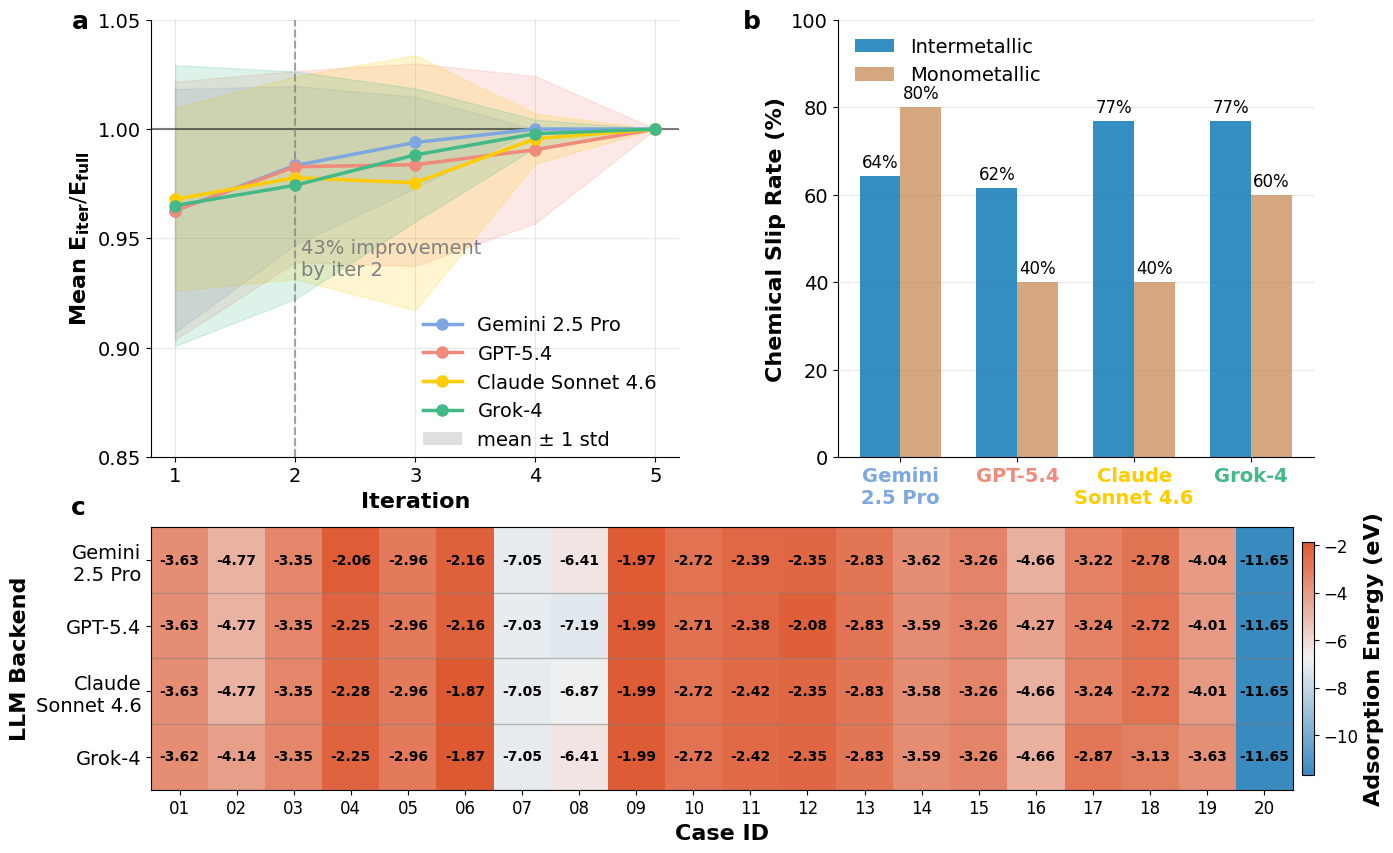

Done: Figure 4 saved in ONE figure with all 3 panels


In [ ]:


# ============================================================
# FIGURE 3: ALL 3 PANELS IN ONE FIGURE
# Layout: 2 rows
#   Row 1: Panel a (left) + Panel b (right)
#   Row 2: Panel c (full width)
# ============================================================

# ---- Define colors and labels ----
# Display order: [Gemini 2.5 Pro, GPT-5.4, Claude Sonnet 4.6, Grok-4]
backend_display_order = ['gemini', 'gpt', 'claude', 'grok4']
backend_display_labels = ['Gemini 2.5 Pro', 'GPT-5.4', 'Claude Sonnet 4.6', 'Grok-4']
backend_display_colors = ['#0173b2', '#cc78bc', '#ca9161', '#de8f05']

# ---- Create figure ----
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 0.6], hspace=0.2, wspace=0.15, width_ratios=[1, 0.1, 0.9])

# =========================
# PANEL A: Ratio Convergence
# =========================
ax_a = fig.add_subplot(gs[0, 0])

iterations = [1, 2, 3, 4, 5]

# Map raw backend keys to display group
panel_a_map = {
    'gemini': ('gemini', 'Gemini 2.5 Pro', '#7EA6E0'),
    'openai_gpt54': ('gpt', 'GPT-5.4', '#F08A7B'),
    'anthropic_sonnet46': ('claude', 'Claude Sonnet 4.6', '#FFCC00'),
    'grok4': ('grok4', 'Grok-4', '#43B988'),
}

# Plot in display order
for raw_backend in ['gemini', 'openai_gpt54', 'anthropic_sonnet46', 'grok4']:
    bdata = df_ratio[df_ratio['backend'] == raw_backend]
    if len(bdata) == 0:
        continue
    _, label, color = panel_a_map[raw_backend]
    mean_ratio, std_ratio = [], []
    for it in iterations:
        vals = bdata[bdata['iteration'] == it]['ratio']
        if len(vals) > 0:
            mean_ratio.append(vals.mean())
            std_ratio.append(vals.std(ddof=1))
        else:
            mean_ratio.append(np.nan)
            std_ratio.append(np.nan)
    mean_ratio = np.array(mean_ratio, dtype=float)
    std_ratio = np.array(std_ratio, dtype=float)

    ax_a.plot(iterations, mean_ratio, 'o-', color=color, label=label,
             linewidth=2.5, markersize=8, zorder=3)
    std_coeff = 1
    fill_label = 'mean ± 1 std' if raw_backend == 'grok4' else None  # Only label the last one to avoid legend clutter
    ax_a.fill_between(iterations, mean_ratio - std_coeff * std_ratio, mean_ratio + std_coeff * std_ratio,
                      color=color, alpha=0.18, zorder=2, label=fill_label)



ax_a.axhline(y=1.0, color='black', linewidth=1.5, alpha=0.5, linestyle='-')
ax_a.set_xlabel('Iteration', fontsize=16, fontweight='bold')
ax_a.set_ylabel(r'Mean $\mathbf{E}_{\mathbf{iter}} / \mathbf{E}_{\mathbf{full}}$', fontsize=16, fontweight='bold')
ax_a.set_xticks([1, 2, 3, 4, 5])
ax_a.set_xticklabels(['1', '2', '3', '4', '5'], fontsize=14)
ax_a.tick_params(axis='y', labelsize=14)

handles, labels = ax_a.get_legend_handles_labels()
legend_handles = []
legend_labels = []
for h, l in zip(handles, labels):
    if l == 'mean ± 1 std':
        legend_handles.append(Patch(facecolor='#b0b0b0', edgecolor='none', alpha=0.4))
        legend_labels.append(l)
    else:
        legend_handles.append(h)
        legend_labels.append(l)
ax_a.legend(legend_handles, legend_labels, loc=(0.5, 0.0), fontsize=14, framealpha=0.9, frameon=False)

ax_a.grid(True, alpha=0.3)
ax_a.set_axisbelow(True)
ax_a.axvline(x=2, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, zorder=2)

# Set y-limits from data
ax_a.set_ylim(0.85, 1.05)
ax_a.set_yticks(np.arange(0.85, 1.05, 0.05))

# Scheme 3: use all ratio samples (sample-count weighted)
iter1_vals = df_ratio[df_ratio['iteration'] == 1]['ratio'].dropna().to_numpy(dtype=float)
iter2_vals = df_ratio[df_ratio['iteration'] == 2]['ratio'].dropna().to_numpy(dtype=float)
if len(iter1_vals) > 0 and len(iter2_vals) > 0:
    baseline = float(np.abs(iter1_vals.mean() - 1.0))
    current = float(np.abs(iter2_vals.mean() - 1.0))
    improvement_pct = 100.0 * (baseline - current) / max(baseline, 1e-12)
    improv_text = f'{improvement_pct:.0f}% improvement \nby iter 2'
else:
    improv_text = 'N/A improvement\nby iter 2'

ax_a.text(2.05, 0.95, improv_text, fontsize=14, color='gray', va='top')
ax_a.text(-0.15, 0.98, 'a', transform=ax_a.transAxes, fontsize=18, fontweight='bold')

# remove upper and right spines
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)

# =========================
# PANEL B: Chemical Slip
# =========================
ax_b = fig.add_subplot(gs[0, 2])

# Raw keys from slip_analysis.json
slip_raw_order = ['gemini', 'openai_gpt54', 'anthropic_claude', 'grok4']
slip_labels = ['Gemini\n2.5 Pro', 'GPT-5.4', 'Claude\nSonnet 4.6', 'Grok-4']

interm = []
monom = []
for key in slip_raw_order:
    inter = slip_data['by_surface_family']['intermetallic'].get(key, 0)
    mono = slip_data['by_surface_family']['monometallic'].get(key, 0)
    interm.append(inter * 100)
    monom.append(mono * 100)

x = np.arange(4)
w = 0.35
bars1 = ax_b.bar(x - w/2, interm, w, label='Intermetallic', color=backend_display_colors[0], alpha=0.8)
bars2 = ax_b.bar(x + w/2, monom, w, label='Monometallic', color=backend_display_colors[2], alpha=0.8)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax_b.text(bar.get_x()+bar.get_width()/2., h+1, f'{h:.0f}%',
                 ha='center', va='bottom', fontsize=12)

ax_b.set_ylabel('Chemical Slip Rate (%)', fontsize=16, fontweight='bold')
ax_b.set_xticks(x)
ax_b.set_xticklabels(slip_labels, fontsize=14)
# Color x-tick labels using colors from panel_a_map and make them bold
slip_to_panel_map = {'gemini':'gemini', 'openai_gpt54':'openai_gpt54', 'anthropic_claude':'anthropic_sonnet46', 'grok4':'grok4'}
slip_colors = [panel_a_map[slip_to_panel_map.get(k, k)][2] if slip_to_panel_map.get(k, k) in panel_a_map else '#000000' for k in slip_raw_order]
for tick, color in zip(ax_b.get_xticklabels(), slip_colors):
    tick.set_color(color)
    tick.set_fontsize(14)
    tick.set_fontweight('bold')
ax_b.tick_params(axis='y', labelsize=14)
ax_b.legend(loc='upper left', fontsize=14, framealpha=0.9, frameon=False)
ax_b.set_ylim(0, 100)
ax_b.grid(True, alpha=0.3, axis='y')
ax_b.set_axisbelow(True)
ax_b.text(-0.2, 0.98, 'b', transform=ax_b.transAxes, fontsize=18, fontweight='bold')
# remove upper and right spines
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)


# =========================
# PANEL C: 4-Backend Agreement Heatmap
# =========================
ax_c = fig.add_subplot(gs[1, :])
ax_c.set_xlabel('Case ID', fontsize=14, fontweight='bold')

# ablation_4backend columns: ['claude', 'gemini', 'gpt', 'grok']
# Reorder to display: [gemini, gpt, claude, grok]
panel_c_order = ['gemini', 'gpt', 'claude', 'grok']
panel_c_labels = ['Gemini\n2.5 Pro', 'GPT-5.4', 'Claude\nSonnet 4.6', 'Grok-4']
pivot_ordered = pivot[panel_c_order].copy().T

color_cmap = (sns.diverging_palette(240, 20, s=85, l=55, center='light', as_cmap=True)
              if sns is not None else plt.get_cmap('RdYlBu_r'))
im = ax_c.imshow(pivot_ordered.values, cmap=color_cmap, aspect='auto')

ax_c.set_xticks(np.arange(len(pivot_ordered.columns)))
ax_c.set_xticklabels([f'{i:02d}' for i in pivot_ordered.columns], fontsize=12)
ax_c.set_yticks(np.arange(len(pivot_ordered.index)))
ax_c.set_yticklabels(panel_c_labels, fontsize=14)

ax_c.set_xlabel('Case ID', fontsize=16, fontweight='bold')
ax_c.set_ylabel('LLM Backend', fontsize=16, fontweight='bold')

# Add horizontal divider lines between backends
for y_val in np.arange(0.5, len(pivot_ordered.index)):
    ax_c.hlines(y_val, -0.5, len(pivot_ordered.columns)-0.5, colors='gray', linewidths=1, linestyles='-', alpha=0.5)

cbar = plt.colorbar(im, ax=ax_c, fraction=0.01, pad=0.008)
cbar.set_label('Adsorption Energy (eV)', fontsize=16, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

for i in range(len(pivot_ordered)):
    for j in range(len(pivot_ordered.columns)):
        value = pivot_ordered.iloc[i, j]
        color = 'black'
        ax_c.text(j, i, f'{value:.2f}', ha='center', va='center',
                 fontsize=10, color=color, fontweight='bold')

ax_c.text(-0.07, 1.05, 'c', transform=ax_c.transAxes, fontsize=18, fontweight='bold')

# =========================
# SAVE & DISPLAY
# =========================
outdir = './'

plt.savefig(f'{outdir}/figure4_complete.png', dpi=300, bbox_inches='tight')
print(f'Saved: {outdir}/figure4_complete.png')
plt.show()
print('Done: Figure 4 saved in ONE figure with all 3 panels')